# Análise exploratória para dados espaço-temporais
Neste notebook apresentamos alguns conceitos básicos para a análise de dados com componentes geográficos e temporais. 

Trabalharemos num primeiro momento com dados fictícios, para apresentar o conceito de forma clara. 

Depois, em outra oportunidade, utilizaremos tais métodos aqui apresentados para realizar uma análise exploratória de dados com bases reais.

Então para começar, suponha que temos uma base de dados $Z$, com $ Z \in \mathbb{R}^{T \times N} $, onde:

- $ T $ é o número de períodos temporais
- $ N $ é o número de regiões geográficas

Para facilitar, imagine que tal base traz informações sobre o consumo de energia elétrica para 7 regiões de São Paulo, ao longo de 5 anos, de 2020 a 2025.

Dessa forma, o conjunto de dados tem a seguinte dimensionalidade $ Z \in \mathbb{R}^{5 \times 7} $.
É isso que criaremos nas seguintes linhas de código. Criaremos esse conjunto de dados fictício, com uma matrix 5x7.


In [2]:
import numpy as np
from scipy.spatial.distance import cdist
import matplotlib.pyplot as plt


T = 5  # Número de anos
N = 7 # Número de regiões

TEMPORAL_LAG = 1 # definimos o lag temporal
SPATIAL_LAG = 1 # definimos o lag espacial
REGION_VIEW = 2 # definimos a região de visualização


def plot_matrix(matrix: np.ndarray, 
                title: str, 
                xlabel: str, 
                ylabel: str, 
                legend_label: str, 
                yticks=None, 
                xticks=None, 
                display=None, 
                show_values=None, 
                figsize=(8, 6)) -> None:
    """
    Plota uma matriz como uma imagem com valores exibidos.
    Args:
        matrix (np.ndarray): Matriz a ser plotada.
        title (str): Título do gráfico.
        xlabel (str): Rótulo do eixo x.
        ylabel (str): Rótulo do eixo y.
        legend_label (str): Rótulo da legenda.
        yticks (list, optional): Rótulos para o eixo y. 
                                Se None, usa índices padrão.
        xticks (list, optional): Rótulos para o eixo x. 
                                Se None, usa índices padrão.
        display (bool, optional): Se True, exibe o gráfico. 
                                    Padrão é True.
        show_values (bool, optional): Se True, exibe os valores 
                                    na matriz. Padrão é True.
        figsize (tuple, optional): Tamanho da figura. Padrão 
                                    é (8, 6).
    Raises:
        ValueError: Se a matriz não for um objeto numpy.ndarray.
    Returns:
        None: Exibe o gráfico.
    """
    if not isinstance(matrix, np.ndarray):
        raise ValueError("A matriz deve ser um objeto numpy.ndarray.")
    Nr, Nc = matrix.shape
    if xticks is None:
        xticks = range(Nc)
    if yticks is None:
        yticks = range(Nr)
    if display is None:
        display = True
    if show_values is None:
        show_values = True
    plt.figure(figsize=figsize)
    if np.all(matrix >= 0):
        plt.imshow(np.round(matrix, 2), cmap='coolwarm')
    else:
        plt.imshow(np.round(matrix, 2), cmap='coolwarm')
    plt.colorbar(label=legend_label)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.yticks(range(Nr), yticks) # type: ignore
    plt.xticks(range(Nc), xticks) # type: ignore
    if show_values:
        for i in range(Nr):
            for j in range(Nc):
                plt.text(j, 
                         i, 
                         f"{matrix[i, j]:.2f}", 
                         ha='center', 
                         va='center', 
                         color='black')
    plt.gca().invert_yaxis()
    if display:
        # Draw a red rectangle around the REGION_VIEW area
        plt.gca().add_patch(
            plt.Rectangle( # type: ignore
            (-0.5, REGION_VIEW - 0.5), Nc, 1,
            fill=False, edgecolor='black', linewidth=3
            )
        )
    plt.show()

def plot_regions(coords, colors=None, 
                 title = "Localização das Regiões no Espaço", 
                 legend_label="Valor", 
                 figsize=(8, 6)):
    
    """
    Plota as regiões em um gráfico de dispersão.
    Args:
        coords (list of tuples): Lista de coordenadas (x, y) das regiões.
        colors (list, optional): Lista de cores para cada região. 
                                Se None, usa cor padrão.
        title (str, optional): Título do gráfico. 
                                Padrão é "Localização das Regiões no Espaço".
        legend_label (str, optional): Rótulo da legenda. 
                                    Padrão é "Valor".
        figsize (tuple, optional): Tamanho da figura. 
                                Padrão é (8, 6).
    Returns:
        None: Exibe o gráfico.
    """
    plt.figure(figsize=figsize)
    x_coords = [c[0] for c in coords]
    y_coords = [c[1] for c in coords]
    if colors is not None:
        scatter = plt.scatter(x_coords, y_coords, c=colors, cmap='coolwarm', s=100)
        plt.colorbar(label=legend_label)
    else:
        scatter = plt.scatter(x_coords, y_coords, c='blue', s=100)
    for i, (x, y) in enumerate(coords):
        plt.text(x - 0.05, y, f"Região {i}", fontsize=12, ha='right', va='bottom')
    plt.title(title)
    plt.xlabel("Coordenada X")
    plt.ylabel("Coordenada Y")
    plt.grid(True, alpha=0.5) 
    plt.show()

Número de anos: 5, Número de localidades: 7 

Definindo lag temporal: 1 e lag espacial: 1

Dimensão da matriz dos dados T x N (5, 7) 

Matriz dos dados: 
 [[5 4 4 2 0 5 8]
 [0 8 8 2 6 1 7]
 [7 3 0 9 4 8 6]
 [7 7 1 3 4 4 0]
 [5 1 7 6 9 7 3]]


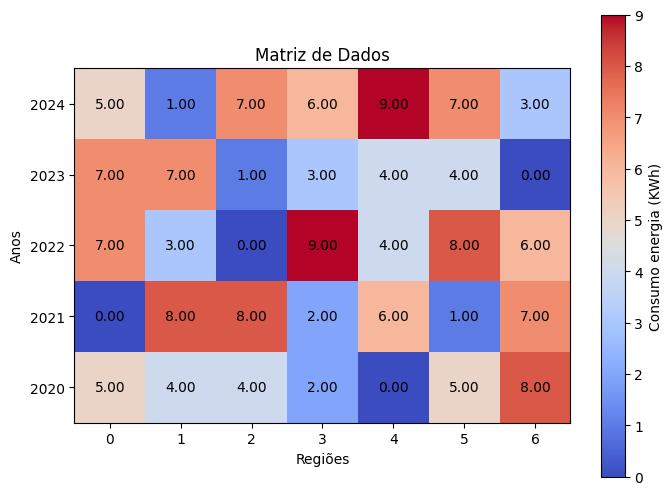

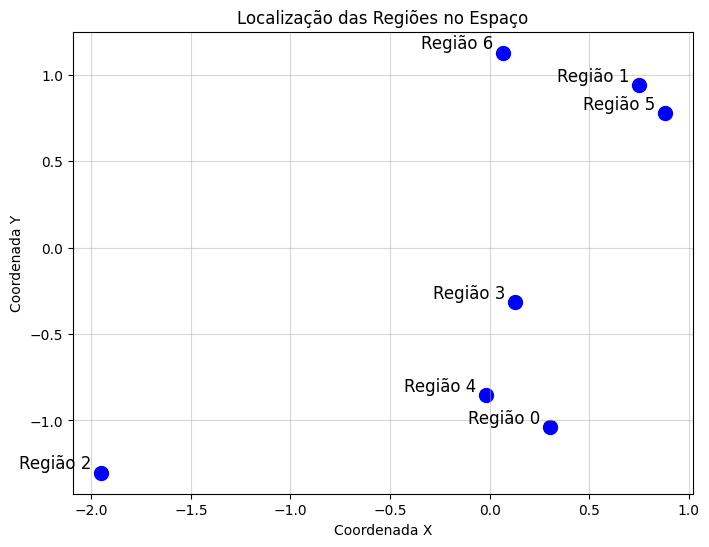

In [3]:
rng = np.random.default_rng(42)
coords = [(rng.normal(0, 1), rng.normal(0, 1)) for _ in range(N)]

# Gerando dados aleatórios para a matriz de dados
Z = rng.integers(0, 10, size=(T, N))

print(f"Número de anos: {T}, Número de localidades: {N} \n")
print(f"Definindo lag temporal: {TEMPORAL_LAG} e lag espacial: {SPATIAL_LAG}\n")
print("Dimensão da matriz dos dados T x N", Z.shape, "\n")
print("Matriz dos dados: \n",Z)
plot_matrix(matrix=Z, 
            title="Matriz de Dados", 
            xlabel="Regiões", 
            ylabel="Anos", 
            legend_label="Consumo energia (KWh)",
            yticks= range(2020, 2020+T),
            display=False
            )
plot_regions(coords)

## Matriz de covariância Empírica

Para calcular a **covariância empírica** em dados espaço-temporais, seguimos alguns passos fundamentais:

1. **Matriz de Dados $Z$**: Considere uma matriz $Z \in \mathbb{R}^{T \times N}$, onde $T$ é o número de períodos temporais (anos, por exemplo) e $N$ é o número de regiões geográficas.

2. **Cálculo da Média Temporal ($\bar{Z}$)**: 
    - Para cada região, calcule a média dos valores ao longo dos $T$ anos.
    - Isso resulta em um vetor $\bar{Z} \in \mathbb{R}^{1 \times N}$, onde cada elemento representa a média temporal de uma região:
      $$
      \bar{Z}_j = \frac{1}{T} \sum_{t=1}^T Z_{t, j}
      $$
      para cada região $j$.

3. **Centralização dos Dados**:
    - Subtraia a média temporal de cada região dos valores correspondentes em $Z$:
      $$
      Z_c = Z - \bar{Z}
      $$
    - Isso garante que estamos analisando apenas as variações em torno da média de cada localidade.

4. **Cálculo da Covariância Empírica**:
    - A matriz de covariância empírica (sem defasagem temporal) é dada por:
      $$
      C = \frac{1}{T} Z_c^\top Z_c
      $$
    - Cada elemento $C_{ij}$ representa a covariância entre as regiões $i$ e $j$ ao longo do tempo.

Esse procedimento permite quantificar como as variações no consumo (ou outra variável de interesse) em diferentes regiões estão relacionadas ao longo dos anos.

Dados originais (Z):
 [[5 4 4 2 0 5 8]
 [0 8 8 2 6 1 7]
 [7 3 0 9 4 8 6]
 [7 7 1 3 4 4 0]
 [5 1 7 6 9 7 3]]

Média temporal por região: [4.8 4.6 4.  4.4 4.6 5.  4.8]

Matriz de dados centralizada (Zc):
 [[ 0.2 -0.6  0.  -2.4 -4.6  0.   3.2]
 [-4.8  3.4  4.  -2.4  1.4 -4.   2.2]
 [ 2.2 -1.6 -4.   4.6 -0.6  3.   1.2]
 [ 2.2  2.4 -3.  -1.4 -0.6 -1.  -4.8]
 [ 0.2 -3.6  3.   1.6  4.4  2.  -1.8]]

Matriz de covariância empírica (C):
 [[ 6.56 -3.08 -6.8   3.68 -1.88  4.8  -3.64]
 [-3.08  6.64  0.4  -4.64 -1.76 -5.6  -0.28]
 [-6.8   0.4  10.   -3.8   4.6  -3.8   2.6 ]
 [ 3.68 -4.64 -3.8   7.44  2.56  5.6  -0.72]
 [-1.88 -1.76  4.6   2.56  8.64  0.4  -3.48]
 [ 4.8  -5.6  -3.8   5.6   0.4   6.   -0.8 ]
 [-3.64 -0.28  2.6  -0.72 -3.48 -0.8   8.56]]


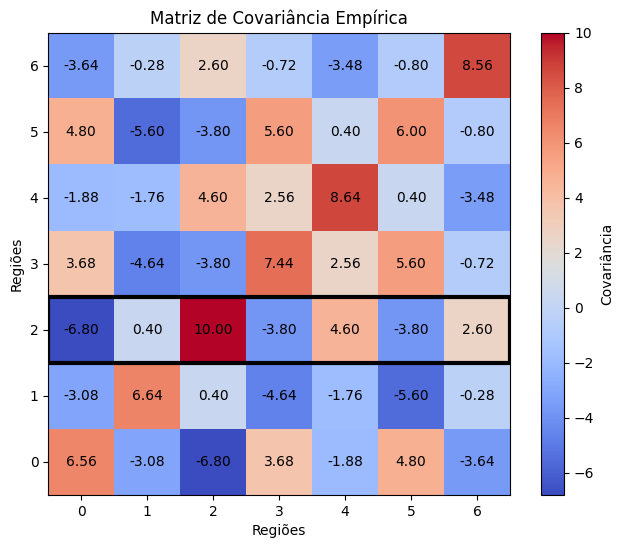

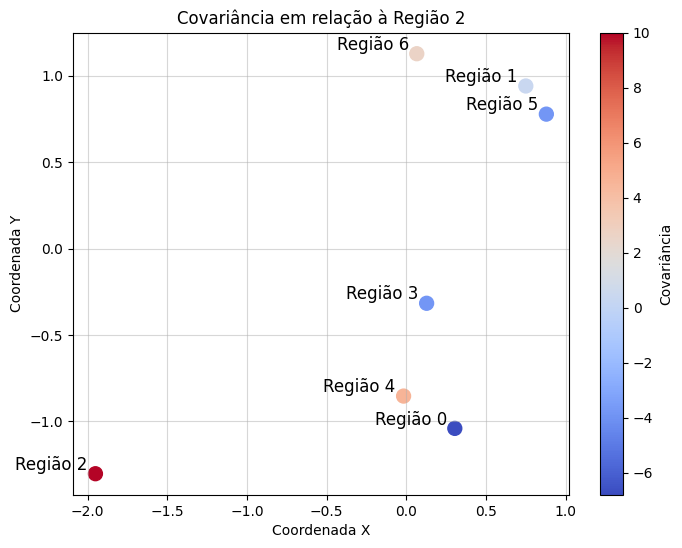

In [4]:
print("Dados originais (Z):\n", Z)
print()
# Calculando a média temporal para cada região
mu = Z.mean(axis=0)
print("Média temporal por região:", mu)
print()
# Centralizando os dados
Zc = Z - mu
print("Matriz de dados centralizada (Zc):\n", Zc)
print()
# Calculando a matriz de covariância empírica (sem defasagem)
C = (Zc.T @ Zc) / T
print("Matriz de covariância empírica (C):\n", C)
plot_matrix(matrix=C, 
            title="Matriz de Covariância Empírica", 
            xlabel="Regiões", 
            ylabel="Regiões", 
            legend_label="Covariância")

plot_regions(coords=coords, 
             colors=C[REGION_VIEW], 
             title = f"Covariância em relação à Região {REGION_VIEW}", 
             legend_label="Covariância")

## Matriz de Covariância Empírica com Lags Temporais

A **matriz de covariância empírica com defasagem temporal** (ou lag temporal) é uma generalização da matriz de covariância tradicional, permitindo analisar como as variações em diferentes regiões estão relacionadas não apenas no mesmo instante, mas também ao longo do tempo.

### Definição

Dada uma matriz de dados $Z \in \mathbb{R}^{T \times N}$, onde $T$ é o número de períodos temporais e $N$ o número de regiões, a matriz de covariância empírica com lag $\delta$ é definida como:

$$
C^{(\delta)} = \frac{1}{T - \delta} \sum_{t = \delta}^{T - 1} (Z_t - \bar{Z})^\top (Z_{t - \delta} - \bar{Z})
$$

- $ Z_t \in \mathbb{R}^{1 \times N} $  representa o vetor de observações no tempo $t$.
- $ \bar{Z} \in \mathbb{R}^{1 \times N} $ é o vetor de médias temporais de cada região.
- $\delta$ é o lag temporal (defasagem).
- $ C^{(\delta)} \in \mathbb{R}^{N \times N} $ representa a covariância entre variáveis com defasagem $ \delta $

### Interpretação

- Quando $\delta = 0$, recuperamos a matriz de covariância usual, que mede a relação entre regiões no mesmo instante de tempo.
- Para $\delta > 0$, a matriz $C^{(\delta)}$ mede como as variações em uma região no tempo $t$ estão relacionadas com as variações em outra (ou na mesma) região no tempo $t - \delta$.

### Aplicação

Esse conceito é fundamental para analisar dependências temporais em dados espaço-temporais, permitindo identificar padrões de persistência, propagação ou defasagem de fenômenos entre diferentes regiões ao longo do tempo.

No código abaixo, mostramos como calcular essa matriz tanto de forma iterativa (com laços for) quanto de forma vetorial, facilitando a análise e a visualização dessas relações espaço-temporais.

Cálculo sem otimização da matriz de covariância:

In [5]:
C = np.zeros((N, N)) # inicializando a matriz de covariância
start_year = 2020
# Inicializando a matriz de covariância como uma matriz N x N de zeros
for t in range(TEMPORAL_LAG, T):
    print(f"------------- Anos {start_year+ t - TEMPORAL_LAG} e {start_year + t}  -------------")
    zt = Z[t, :] # dados do ano t
    zt_lag = Z[t - TEMPORAL_LAG, :] # dados do ano t - TEMPORAL_LAG
    print(f"Dados do ano {start_year + t - TEMPORAL_LAG}:", zt_lag)
    print(f"Dados do ano {start_year + t}:", zt)
    print(f"Média {T} anos:", np.mean(Z, axis=0))
    zt_lag_centered = zt_lag - np.mean(Z, axis=0) # centralizando os dados do ano t - TEMPORAL_LAG
    zt_centered = zt - np.mean(Z, axis=0) # centralizando os dados do ano t
    print(f"Dados do ano {start_year + t - TEMPORAL_LAG} menos média:", zt_lag_centered)
    print(f"Dados do ano {start_year + t} menos média:", zt_centered)
    # Calculando a diferença entre os anos
    outer = np.outer(zt_centered, zt_lag_centered)
    print(f"Multiplicação dos dados entre anos {start_year + t - TEMPORAL_LAG} e {t}: \n", outer)
    C += outer
    # Calculando a matriz de covariância
    
    print("Matriz de covariância acumulada: \n", C)
    print()
# Normalizando a matriz de covariância
C /= (T - TEMPORAL_LAG)
print("\033[1mMatriz de covariância normalizada: \n", C, "\033[0m")

------------- Anos 2020 e 2021  -------------
Dados do ano 2020: [5 4 4 2 0 5 8]
Dados do ano 2021: [0 8 8 2 6 1 7]
Média 5 anos: [4.8 4.6 4.  4.4 4.6 5.  4.8]
Dados do ano 2020 menos média: [ 0.2 -0.6  0.  -2.4 -4.6  0.   3.2]
Dados do ano 2021 menos média: [-4.8  3.4  4.  -2.4  1.4 -4.   2.2]
Multiplicação dos dados entre anos 2020 e 1: 
 [[ -0.96   2.88  -0.    11.52  22.08  -0.   -15.36]
 [  0.68  -2.04   0.    -8.16 -15.64   0.    10.88]
 [  0.8   -2.4    0.    -9.6  -18.4    0.    12.8 ]
 [ -0.48   1.44  -0.     5.76  11.04  -0.    -7.68]
 [  0.28  -0.84   0.    -3.36  -6.44   0.     4.48]
 [ -0.8    2.4   -0.     9.6   18.4   -0.   -12.8 ]
 [  0.44  -1.32   0.    -5.28 -10.12   0.     7.04]]
Matriz de covariância acumulada: 
 [[ -0.96   2.88   0.    11.52  22.08   0.   -15.36]
 [  0.68  -2.04   0.    -8.16 -15.64   0.    10.88]
 [  0.8   -2.4    0.    -9.6  -18.4    0.    12.8 ]
 [ -0.48   1.44   0.     5.76  11.04   0.    -7.68]
 [  0.28  -0.84   0.    -3.36  -6.44   0.     4.4

De forma vetorial, isso equivale a:

$$
C^{(\delta)} = \frac{1}{T - \delta} Z_c^{(\delta)^\top} Z_c^{(-\delta)}
$$

**onde:**

- $ Z_c^{(\delta)} = Z_c[\delta:] $ são os dados a partir do tempo $ \delta $
- $ Z_c^{(-\delta)} = Z_c[:-\delta] $ são os dados até o tempo $ T - \delta $
- $ C^{(\delta)} \in \mathbb{R}^{N \times N} $ representa a covariância entre variáveis com defasagem $ \delta $


[[-1.56  1.83 -0.15  4.02  5.93 -0.6  -2.21]
 [ 1.43 -4.99 -1.3   2.94 -4.29  4.3   6.88]
 [ 5.   -1.   -3.25 -4.5  -6.    1.   -3.5 ]
 [-5.53  5.79  4.8  -3.49  4.34 -6.05 -1.73]
 [ 2.88  2.16 -3.3  -2.71 -2.39 -0.95 -4.67]
 [-3.25  4.75  2.5  -1.25  5.5  -4.25 -4.25]
 [-4.96  1.53  7.35 -6.93 -1.12 -4.35  3.14]]


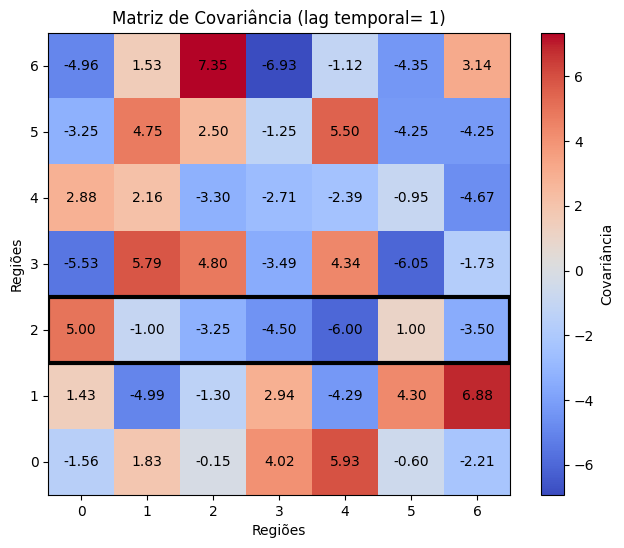

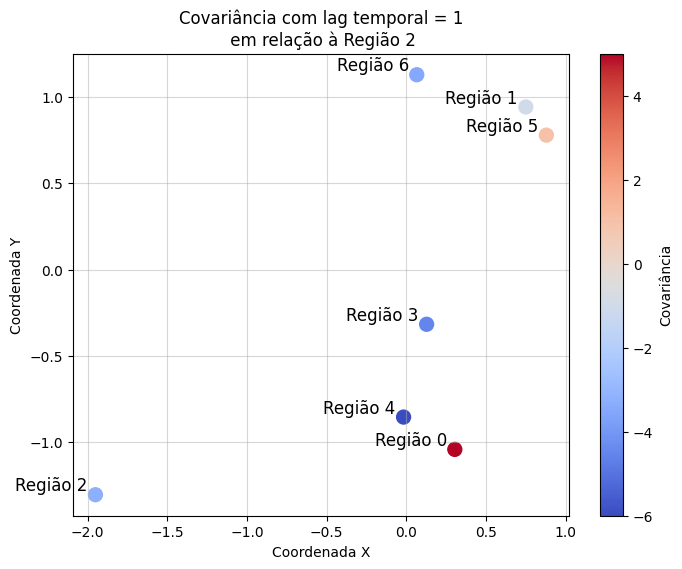

In [6]:
def covariance_func(Z, temporal_lag):
    T, _ = Z.shape
    Zc = (Z - Z.mean(axis=0))
    if temporal_lag == 0:
        return (Zc.T @ Zc) / T
    return (Zc[temporal_lag:].T @ Zc[:-temporal_lag]) / (T - temporal_lag)

C = covariance_func(Z, TEMPORAL_LAG)
print(C)

plot_matrix(matrix=C, 
            title=f"Matriz de Covariância (lag temporal= {TEMPORAL_LAG})", 
            xlabel="Regiões", 
            ylabel="Regiões", 
            legend_label="Covariância")

plot_regions(coords=coords, 
             colors=C[REGION_VIEW], 
             title=f"Covariância com lag temporal = {TEMPORAL_LAG}"
             f"\n em relação à Região {REGION_VIEW}", 
             legend_label="Covariância")    

## Matriz de Covariância Empírica com Lags Temporais e Espaciais

A **matriz de covariância empírica com lags temporais e espaciais** é definida como:

$$
C^{(\delta_t, \delta_s)} = \frac{1}{|N_s(\delta_s)| \cdot |N_t(\delta_t)|} \sum_{(i, j) \in N_s(\delta_s)} \sum_{(t, r) \in N_t(\delta_t)} \left[ Z(s_i, t) - \bar{Z}(s_i) \right] \left[ Z(s_j, r) - \bar{Z}(s_j) \right]
$$

- $N_s(\delta_s)$: conjunto de pares de regiões $(s_i, s_j)$ separados por distância espacial $\delta_s$.
- $N_t(\delta_t)$: conjunto de pares de tempos $(t, r)$ separados por lag temporal $\delta_t$ (por exemplo, $r = t - \delta_t$).
- $\bar{Z}(s_i)$: média temporal da região $s_i$.
- $|N_s(\delta_s)|$: número de pares espaciais considerados.
- $|N_t(\delta_t)|$: número de pares temporais considerados.

Essa definição garante que a covariância é calculada considerando todos os pares de regiões e tempos com as defasagens especificadas, normalizando pelo número de pares.

### Interpretação

- A matriz $C^{(\delta_t, \delta_s)}$ mede como as variações em uma região $s_i$ em um tempo $t$ estão relacionadas com as variações em outra região $s_j$ em um tempo defasado $r = t - \delta_t$, considerando apenas pares de regiões separados por uma distância espacial $\delta_s$.
- Valores altos de covariância indicam que mudanças em uma região tendem a ser acompanhadas por mudanças em outra região, após um certo intervalo de tempo e a uma determinada distância espacial.
- Permite identificar padrões de propagação espacial e temporal de fenômenos, como persistência, dispersão ou influência entre regiões.

### Aplicação

- Utilizada para analisar dependências espaço-temporais em dados ambientais, epidemiológicos, econômicos, entre outros.
- Ajuda a entender como eventos em uma região podem influenciar regiões vizinhas ao longo do tempo.
- Fundamental para modelagem espaço-temporal, previsão e identificação de clusters ou padrões de propagação em séries espaço-temporais.

Matriz de distâncias espaciais:
 [[0.   2.03 2.27 0.75 0.37 1.91 2.18]
 [2.03 0.   3.51 1.4  1.95 0.21 0.71]
 [2.27 3.51 0.   2.3  1.99 3.51 3.16]
 [0.75 1.4  2.3  0.   0.56 1.33 1.44]
 [0.37 1.95 1.99 0.56 0.   1.86 1.98]
 [1.91 0.21 3.51 1.33 1.86 0.   0.89]
 [2.18 0.71 3.16 1.44 1.98 0.89 0.  ]]


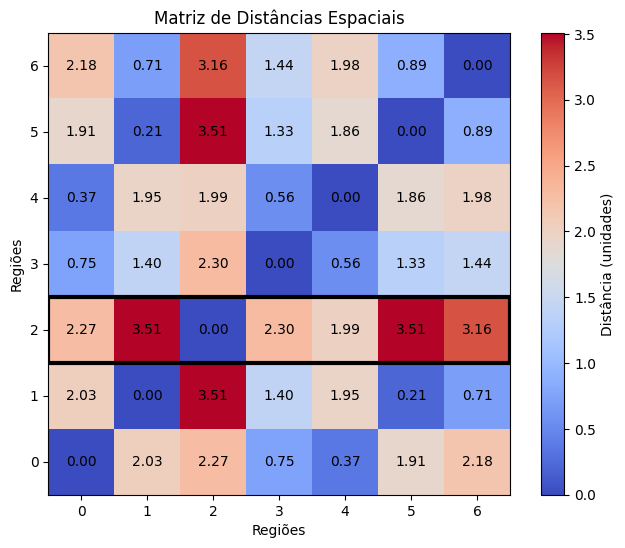

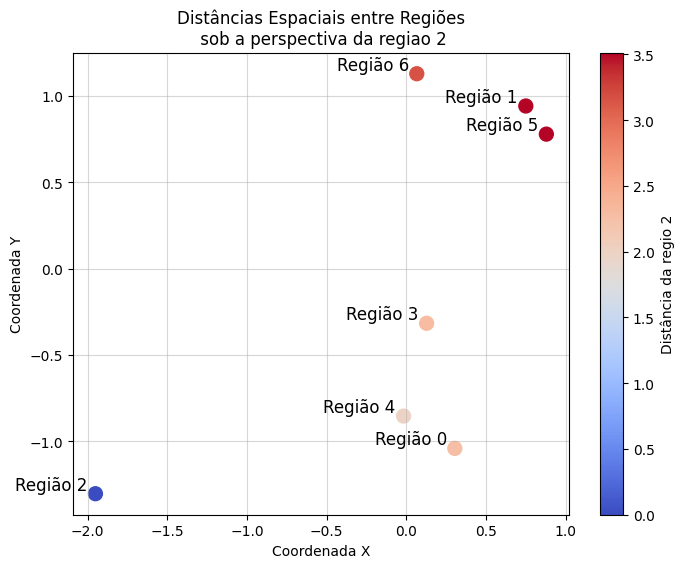

In [7]:
dist_matrix = cdist(coords, coords)
print("Matriz de distâncias espaciais:\n", np.round(dist_matrix, 2))

plot_matrix(matrix=dist_matrix, 
            title="Matriz de Distâncias Espaciais", 
            xlabel="Regiões", 
            ylabel="Regiões", 
            legend_label="Distância (unidades)")

plot_regions(coords, 
             colors=dist_matrix[REGION_VIEW], 
             title="Distâncias Espaciais entre Regiões"
               f"\n sob a perspectiva da regiao {REGION_VIEW}", 
             legend_label=f"Distância da regio {REGION_VIEW}")

A função $ N_s(\delta_s) $ considera pares validos de ponto para todos aqueles pares cuja distância seja menor que o lag.
Já a função $ N_t(\delta_t) $ leva em conta todos os tempos passados do tempo atual a uma diferença igual ao lag definido.

No contexto de dados espaço-temporais, ao estimarmos a covariância entre regiões e tempos defasados, é importante saber quantos pares de observações realmente contribuem para o cálculo, pois nem todos os pares possíveis necessariamente atendem aos critérios de distância espacial (lag espacial) e defasagem temporal (lag temporal) definidos.

Por isso tais funções percorrem todos os pares de regiões e todos os pares de tempos, contando apenas aqueles que satisfazem as condições impostas pelos lags. O resultado é utilizado para normalizar o somatório das covariâncias, garantindo que o estimador seja consistente e interpretavel, mesmo quando a quantidade de pares válidos varia conforme os parâmetros de lag escolhidos.

Esse controle é fundamental para análises corretas em séries espaço-temporais, pois evita viéses decorrentes de diferentes tamanhos de amostra efetiva em cada configuração de lag.

In [8]:
# Construir matriz binária de vizinhança
def make_adjacency_matrix(dist_matrix, spatial_lag):
    adj_matrix = np.zeros((N, N), dtype=int)
    for i in range(N):
        for j in range(N):
            if i != j and dist_matrix[i, j] <= spatial_lag:
                adj_matrix[i, j] = 1

    return adj_matrix

# Criar matriz de adjacência com base na matriz de distâncias
adj_matrix = make_adjacency_matrix(dist_matrix=dist_matrix, 
                                   spatial_lag = SPATIAL_LAG)
print("Matriz de adjacência (vizinhança):\n", adj_matrix)

Matriz de adjacência (vizinhança):
 [[0 0 0 1 1 0 0]
 [0 0 0 0 0 1 1]
 [0 0 0 0 0 0 0]
 [1 0 0 0 1 0 0]
 [1 0 0 1 0 0 0]
 [0 1 0 0 0 0 1]
 [0 1 0 0 0 1 0]]


In [9]:
def get_temporal_spatial_pairs_within_lag(adj_matrix, temporal_lag):
    region_pairs = [(i, j) for i in range(N) for j in range(N) if adj_matrix[i, j]]
    temporal_pairs = [(t, t + temporal_lag) for t in range(T - temporal_lag)]
    return temporal_pairs, region_pairs 

# Obter pares temporais e espaciais dentro do lag
temporal_pairs, region_pairs = get_temporal_spatial_pairs_within_lag(adj_matrix=adj_matrix, 
                                                                     temporal_lag=TEMPORAL_LAG)

print("Pares espaciais (i, j):", region_pairs)
print("Pares temporais (t, t+τ):", temporal_pairs)

Pares espaciais (i, j): [(0, 3), (0, 4), (1, 5), (1, 6), (3, 0), (3, 4), (4, 0), (4, 3), (5, 1), (5, 6), (6, 1), (6, 5)]
Pares temporais (t, t+τ): [(0, 1), (1, 2), (2, 3), (3, 4)]


In [10]:
# Estimador de covariância empírica
def estimate_empirical_covariance(data, region_pairs, temporal_pairs):
    if not temporal_pairs:
        return 0.0
    if not region_pairs:
        return 0.0
    numerador = 0.0
    for (i, j) in region_pairs:
        for (t, r) in temporal_pairs:
            numerador += (data[t, i] - data.mean(axis=0)[i]) * (data[r, j] - data.mean(axis=0)[j])
    
    denominador = len(region_pairs) * len(temporal_pairs)
    return numerador / denominador


# Estimador empírico Ĉ_Z(h ≤ SPATIAL_LAG; τ = TEMPORAL_LAG)
C_hat = estimate_empirical_covariance(data=Z, 
                                      region_pairs=region_pairs, 
                                      temporal_pairs=temporal_pairs)

print(f"Estimador empírico Ĉ_Z(h ≤ {SPATIAL_LAG}; τ = {TEMPORAL_LAG}) = {C_hat:.4f}")

Estimador empírico Ĉ_Z(h ≤ 1; τ = 1) = 1.4825


A função que realiza o cálculo completo da covariancia espaço-temporal é dada abaixo.

In [11]:
def spatial_temporal_lagged_covariance_func(Z, coords, spatial_lag, temporal_lag):
    dist_matrix = cdist(coords, coords)
    adj_matrix = make_adjacency_matrix(dist_matrix, spatial_lag)
    temporal_pairs, region_pairs = get_temporal_spatial_pairs_within_lag(adj_matrix, temporal_lag)
    return estimate_empirical_covariance(Z, region_pairs, temporal_pairs)

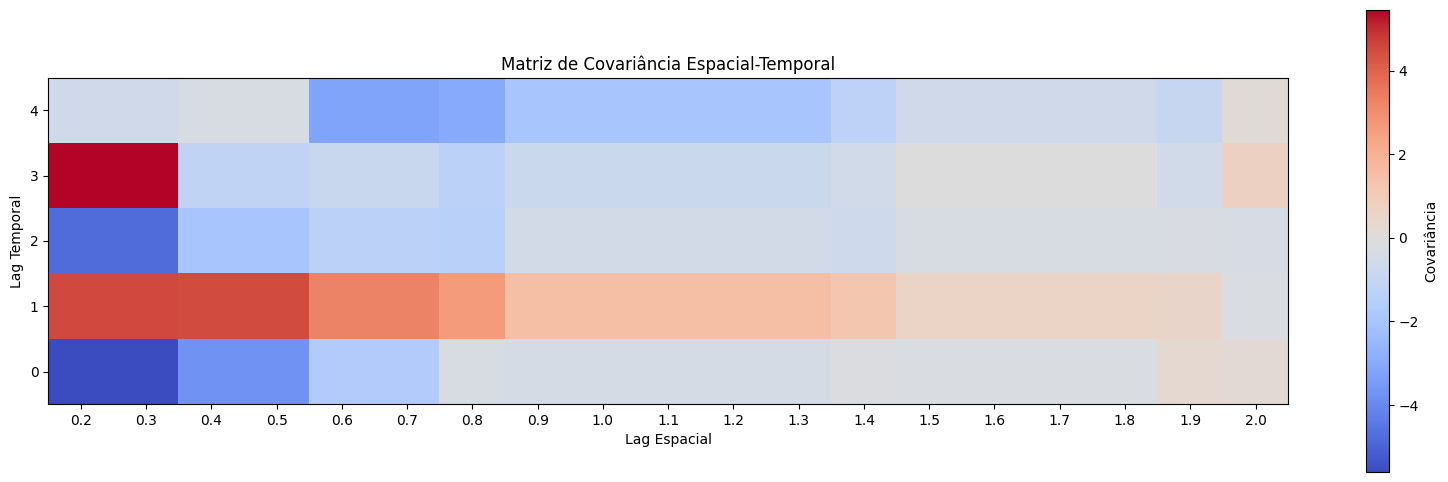

In [12]:
min_nonzero_distance = np.min(dist_matrix[dist_matrix != 0])
spatial_lags = np.arange(min_nonzero_distance, 2.1, 0.1)
temporal_lags = np.arange(0, 5)
Cmap = np.zeros((len(temporal_lags), len(spatial_lags)))

for i, spatial_lag in enumerate(spatial_lags):
    for j, temporal_lag in enumerate(temporal_lags):
        Cmap[j, i] = spatial_temporal_lagged_covariance_func(Z, 
                                                             coords, 
                                                             spatial_lag, 
                                                             temporal_lag
                                                             )

spatial_lags = np.round(spatial_lags, 1)

plot_matrix(matrix=Cmap, 
            title="Matriz de Covariância Espacial-Temporal", 
            xlabel="Lag Espacial", 
            ylabel="Lag Temporal", 
            legend_label="Covariância", 
            xticks=spatial_lags, 
            yticks=temporal_lags , 
            display=False, 
            show_values=False,
            figsize=(20, 6)
            )

## Correlação com lag temporal

A correlação com defasagem temporal $ \delta $ é dada por:

$$
\mathrm{Corr}^{(\delta)}_{ij} = \frac{C^{(\delta)}_{ij}}{\sqrt{C^{(0)}_{ii}} \sqrt{C^{(0)}_{jj}}}
$$
**onde:**
- $ C^{(\delta)}_{ij} $ é o termo da matriz de covariância entre as localizações $ i $ e $ j $ com defasagem $ \delta $
- $ C^{(0)}_{ii} $ e $ C^{(0)}_{jj} $ são as **variâncias** das localizações $ i $ e $ j $
- $ \mathrm{Corr}^{(\delta)}_{ij} \in [-1, 1] $ é o **coeficiente de correlação** com defasagem $ \delta $ entre as localizações $ i $ e $ j $

In [13]:
def correlation_expanded(Z):
    T, N = Z.shape
    Z_mean = Z.mean(axis=0)
    Zc = Z - Z_mean  # Centraliza os dados

    C = np.zeros((N, N))
    for t in range(TEMPORAL_LAG, T):
        zt = Zc[t]
        zt_lag = Zc[t - TEMPORAL_LAG]
        C += np.outer(zt, zt_lag)
    C /= (T - TEMPORAL_LAG)

    stds = np.sqrt(np.diag(covariance_func(Z, 0)))  # Desvios padrão
    D_inv = np.diag(1 / stds)
    Corr = D_inv @ C @ D_inv
    return Corr

corr_matrix = correlation_expanded(Z)
print("Matriz de correlação: \n", np.round(corr_matrix, 2))

Matriz de correlação: 
 [[-0.24  0.28 -0.02  0.58  0.79 -0.1  -0.29]
 [ 0.22 -0.75 -0.16  0.42 -0.57  0.68  0.91]
 [ 0.62 -0.12 -0.32 -0.52 -0.65  0.13 -0.38]
 [-0.79  0.82  0.56 -0.47  0.54 -0.91 -0.22]
 [ 0.38  0.29 -0.36 -0.34 -0.28 -0.13 -0.54]
 [-0.52  0.75  0.32 -0.19  0.76 -0.71 -0.59]
 [-0.66  0.2   0.79 -0.87 -0.13 -0.61  0.37]]


Ou na sua forma vetorial:
$$
\mathrm{Corr}^{(\delta)} = D^{-1/2} C^{(\delta)} D^{-1/2}
$$
**onde:**

- $ C^{(\delta)} $ é a matriz de **covariância empírica** com defasagem temporal $ \delta $
- $ C^{(0)} $ é a matriz de **covariância usual**, sem defasagem (lag zero)
- A matriz $ D $ é uma **matriz diagonal** contendo as variâncias das variáveis (ou seja, as variâncias da matriz de covariância com lag zero $ C^{(0)} $):

$$
D = \mathrm{diag}\left( \sqrt{C^{(0)}_{11}}, \sqrt{C^{(0)}_{22}}, \dots, \sqrt{C^{(0)}_{NN}} \right)
$$

Matriz de correlação (vetorizada): 
 [[-0.24  0.28 -0.02  0.58  0.79 -0.1  -0.29]
 [ 0.22 -0.75 -0.16  0.42 -0.57  0.68  0.91]
 [ 0.62 -0.12 -0.32 -0.52 -0.65  0.13 -0.38]
 [-0.79  0.82  0.56 -0.47  0.54 -0.91 -0.22]
 [ 0.38  0.29 -0.36 -0.34 -0.28 -0.13 -0.54]
 [-0.52  0.75  0.32 -0.19  0.76 -0.71 -0.59]
 [-0.66  0.2   0.79 -0.87 -0.13 -0.61  0.37]]


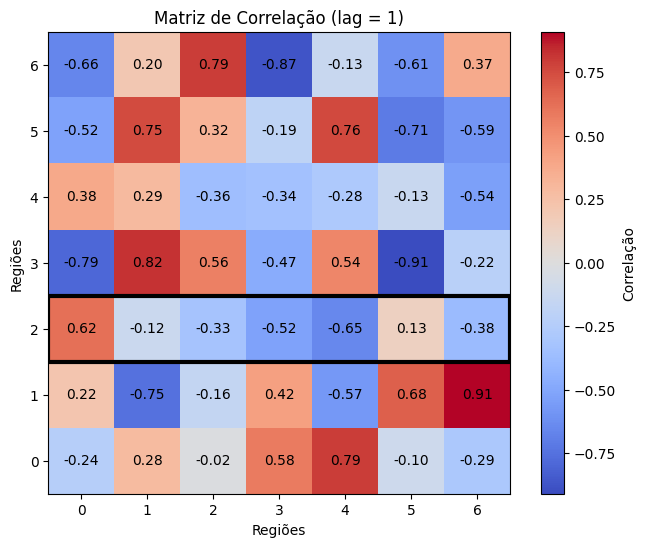

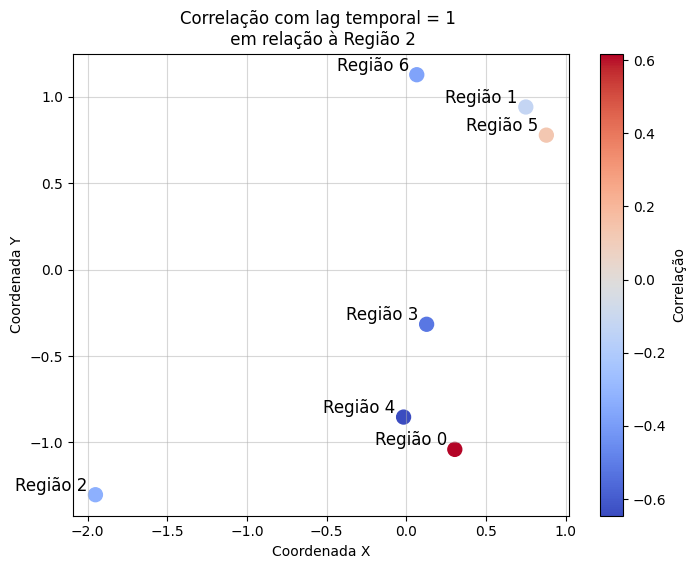

In [14]:
def correlation_vectorized(Z, temporal_lag):
    T, _ = Z.shape
    Zc = Z - Z.mean(axis=0)

    if temporal_lag == 0:
        C = (Zc.T @ Zc) / T
    else:
        C = (Zc[temporal_lag:].T @ Zc[:-temporal_lag]) / (T - temporal_lag)

    stds = np.sqrt(np.diag((Zc.T @ Zc) / T))  # Desvios padrão de C(0)
    D_inv = np.diag(1 / stds)
    Corr = D_inv @ C @ D_inv
    return Corr

corr_matrix_vectorized = correlation_vectorized(Z, TEMPORAL_LAG)

print("Matriz de correlação (vetorizada): \n", np.round(corr_matrix_vectorized, 2))

plot_matrix(matrix=corr_matrix_vectorized, 
            title=f"Matriz de Correlação (lag = {TEMPORAL_LAG})", 
            xlabel="Regiões", 
            ylabel="Regiões", 
            legend_label="Correlação"
            )
plot_regions(coords, 
             colors=corr_matrix_vectorized[REGION_VIEW], 
             title=f"Correlação com lag temporal = {TEMPORAL_LAG} \n em relação à Região {REGION_VIEW}", 
             legend_label="Correlação"
             )